In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI


In [2]:
# Load environment variables
load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")
print(llm.invoke("What is the capital of France?").content)

The capital of France is Paris.


In [4]:
#tavily setup

import os
from langchain_community.tools.tavily_search import TavilySearchResults
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
search_tool = TavilySearchResults(tavily_api_key=os.environ['TAVILY_API_KEY'])

In [5]:
print(search_tool.invoke("What is the capital of France?")[0]['content'])



Paris is the capital and largest city of France. With an estimated population of 2,048,472 in January 2025 in an area of more than 105 km2 (41 sq mi),


In [6]:
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.types import Command, interrupt
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage


In [7]:
model = ChatOpenAI(model="gpt-4o-mini")

In [8]:

def supervisor(state: MessagesState) -> Command[Literal["research_agent", "report_agent", END]]:
    messages = state["messages"]
    last_user_msg = [msg for msg in messages if isinstance(msg, HumanMessage)][-1]
    ai_messages = [msg for msg in messages if isinstance(msg, AIMessage)]
    
    #  Check if a leaf agent already responded
    if ai_messages:
        print(f"[DEBUG] Found existing AI response — finishing the workflow.")
        return Command(goto=END)
    
    # Get the most recent user query
    print(f"[DEBUG] User Query: {last_user_msg.content}")

    # Prompt the LLM to decide the next step
    system_prompt = """
You are a supervisor AI coordinating a workflow between two agents:
- 'research_agent': for gathering information from external sources or answering knowledge-based questions.
- 'report_agent': for generating summaries, writing formal documents, or presenting structured information.

Based on the user query, decide which agent to route the task to.
Respond ONLY with one of the following: 
- "research_agent"
- "report_agent"
- "END"
- Or respond with "none" if the query doesn't fit any category.

Examples:
- "What is the GDP of Brazil in 2024?" → research_agent
- "Write a summary report on our Q1 sales figures." → report_agent
- "Thanks, that’s all I needed." → END
- "What are some good project management tools?" → none
"""

    response = model.invoke([
        HumanMessage(content=system_prompt),
        last_user_msg
    ])

    raw_output = response.content.strip()
    print(f"[DEBUG] LLM Raw Response: {raw_output}")
    
    decision = raw_output.lower()
    
    if decision in ["none", "end"]:
        print("[DEBUG] Supervisor classified query as unrelated or done — finishing.")
        return Command(goto=END)

    if decision not in ["research_agent", "report_agent"]:
        print("[DEBUG] Invalid response from model. Defaulting to END")
        return Command(goto=END)

    print(f"[DEBUG] Routing to agent: {decision}")
    return Command(goto=decision)

In [9]:
state = {"messages": [HumanMessage(content="Write a summary report on our Q1 sales performance")]}
print(supervisor(state))


[DEBUG] User Query: Write a summary report on our Q1 sales performance
[DEBUG] LLM Raw Response: report_agent
[DEBUG] Routing to agent: report_agent
Command(goto='report_agent')


In [10]:
def research_agent(state: MessagesState) -> Command[Literal["medical_research_agent", "financial_research_agent", "supervisor"]]:
    last_user_msg = [msg for msg in state["messages"] if isinstance(msg, HumanMessage)][-1]
    ai_messages = [msg for msg in state["messages"] if isinstance(msg, AIMessage)]
    
    
    if ai_messages:
        print("[DEBUG] Leaf agent responded — returning to supervisor")
        return Command(goto="supervisor")
    
    print(f"[DEBUG] Research Supervisor Received Query: {last_user_msg.content}")

    routing_prompt = """
You are a domain classifier AI for routing research queries.

Route the user query to one of the following agents:
- "medical_research_agent": for health, diseases, treatments, biology, medications, medical stats.
- "financial_research_agent": for topics like economy, markets, GDP, inflation, crypto, stocks, banking.

Respond ONLY with:
- "medical_research_agent"
- "financial_research_agent"

If the query doesn't fit either category, respond with "supervisor".

Examples:
- "What are the symptoms of diabetes?" → medical_research_agent
- "What’s the projected GDP of India in 2025?" → financial_research_agent
- "What are some good productivity tools?" → supervisor
"""

    response = model.invoke([
        HumanMessage(content=routing_prompt),
        last_user_msg
    ])

    route_decision = response.content.strip().lower()
    print(f"[DEBUG] Research Agent Routing Decision: {route_decision}")

    if route_decision not in ["medical_research_agent", "financial_research_agent"]:
        print("[DEBUG] Invalid or unrelated query — returning to supervisor")
        route_decision = "supervisor"

    return Command(goto=route_decision)


In [11]:
state = {"messages": [HumanMessage(content="What are the symptoms of hypertension?")]}
print(research_agent(state))

[DEBUG] Research Supervisor Received Query: What are the symptoms of hypertension?
[DEBUG] Research Agent Routing Decision: medical_research_agent
Command(goto='medical_research_agent')


In [12]:
state = {"messages": [HumanMessage(content="What’s the projected GDP growth of China in 2025?")]}
print(research_agent(state))


[DEBUG] Research Supervisor Received Query: What’s the projected GDP growth of China in 2025?
[DEBUG] Research Agent Routing Decision: financial_research_agent
Command(goto='financial_research_agent')


In [13]:
state = {"messages": [HumanMessage(content="What are some fun weekend activities?")]}
print(research_agent(state))


[DEBUG] Research Supervisor Received Query: What are some fun weekend activities?
[DEBUG] Research Agent Routing Decision: supervisor
[DEBUG] Invalid or unrelated query — returning to supervisor
Command(goto='supervisor')


In [14]:
def financial_research_agent(state: MessagesState) -> Command[Literal["research_agent"]]:
    user_msg = [msg for msg in state["messages"] if isinstance(msg, HumanMessage)][-1]
    query = user_msg.content
    print(f"[DEBUG] Financial Agent received query: {query}")

    try:
        search_results = search_tool.invoke(query)
        if not search_results:
            answer = "Sorry, I couldn’t find any relevant financial data."
        else:
            answer = f" Financial Insight:\n{search_results[0]['content']}"
    except Exception as e:
        print(f"[ERROR] Tavily search failed: {e}")
        answer = "An error occurred while fetching financial data."

    return Command(
        goto="research_agent",
        update={"messages": [AIMessage(content=answer)]}
    )

In [15]:
def medical_research_agent(state: MessagesState) -> Command[Literal["research_agent"]]:
    user_msg = [msg for msg in state["messages"] if isinstance(msg, HumanMessage)][-1]
    query = user_msg.content
    print(f"[DEBUG] Medical Agent received query: {query}")

    try:
        search_results = search_tool.invoke(query)
        if not search_results:
            answer = "Sorry, I couldn’t find any relevant medical information."
        else:
            # Get the top result (you can aggregate more if needed)
            answer = f"🔍 Medical Insight:\n{search_results[0]['content']}"
    except Exception as e:
        print(f"[ERROR] Tavily search failed: {e}")
        answer = "An error occurred while fetching medical information."

    return Command(
        goto="research_agent",
        update={"messages": [AIMessage(content=answer)]}
    )


In [16]:
state = {"messages": [HumanMessage(content="What are the symptoms of hypertension?")]}
print(medical_research_agent(state))

[DEBUG] Medical Agent received query: What are the symptoms of hypertension?
Command(update={'messages': [AIMessage(content="🔍 Medical Insight:\nThe symptoms of severe hypertension are so general that they may look like a number of health conditions. Among those conditions are:Â\n\nDehydration. If your body doesn't have enough fluids, you might get symptoms that are also common with extremely high blood pressure, including nausea, dizziness, fatigue, or confusion. That happens in part because staying hydrated helps Â maintain normal blood pressure. [...] High blood pressure â\x80\x93 also called hypertension â\x80\x93 can lead to serious complications, including stroke, heart disease, kidney disease, and eye problems. Most people with high blood pressure don't have any symptoms until it's severe. Instead of relying on symptoms to alert you, have your blood pressure checked regularly. You may want to learn how to monitor your blood pressure at home. If you do experience symptoms such as

In [17]:
state = {"messages": [HumanMessage(content="What’s the projected GDP growth of China in 2025?")]}
print(financial_research_agent(state))

[DEBUG] Financial Agent received query: What’s the projected GDP growth of China in 2025?
Command(update={'messages': [AIMessage(content=' Financial Insight:\nGiven the growth in consumption and net exports, in order to achieve the GDP growth target, Beijing had to ensure that investment contributed 1.2 percentage points (or 25 percent of GDP growth) in 2024. *   If it is also assumed that domestic consumption and net exports together contribute roughly 3.0–3.5 percentage points to GDP growth, in order to achieve the GDP growth target of 5 percent, Beijing will have to engineer enough of an increase in investment to generate 1.5 to 2.0 percentage points in growth, or a significant increase over the 1.2 percentage points it generated last year. None of this forecasting is especially easy, but estimating the performance of the components of GDP growth needed to achieve China’s growth target has several advantages over predicting and periodically changing the expected GDP growth rate for 

In [18]:
def report_agent(state: MessagesState) -> Command[Literal["summarization_agent", "documentation_agent", "supervisor"]]:
    last_user_msg = [msg for msg in state["messages"] if isinstance(msg, HumanMessage)][-1]
    ai_messages = [msg for msg in state["messages"] if isinstance(msg, AIMessage)]
    
    if ai_messages:
        print("[DEBUG] Leaf agent responded — returning to supervisor")
        return Command(goto="supervisor")
    
    print(f"[DEBUG] Report Supervisor Received Query: {last_user_msg.content}")

    routing_prompt = """
You are a domain classifier AI for routing reporting-related tasks.

Route the user query to one of the following agents:
- "summarization_agent": if the user is asking to summarize content, extract insights, or condense information.
- "documentation_agent": if the user wants to create structured documents like reports, memos, PDFs, DOCX files.

Respond ONLY with:
- "summarization_agent"
- "documentation_agent"

If the task doesn't fit either category, respond with "supervisor".

Examples:
- "Summarize the following customer feedback thread" → summarization_agent
- "Write a quarterly report based on our latest sales data" → documentation_agent
- "List some tools for project management" → supervisor
"""

    response = model.invoke([
        HumanMessage(content=routing_prompt),
        last_user_msg
    ])

    route_decision = response.content.strip().lower()
    print(f"[DEBUG] Report Agent Routing Decision: {route_decision}")

    if route_decision not in ["summarization_agent", "documentation_agent"]:
        print("[DEBUG] Invalid or unrelated query — returning to supervisor")
        route_decision = "supervisor"

    return Command(goto=route_decision)


In [19]:
state = {"messages": [HumanMessage(content="Write a quarterly report based on our latest sales data")]}
print(report_agent(state))


[DEBUG] Report Supervisor Received Query: Write a quarterly report based on our latest sales data
[DEBUG] Report Agent Routing Decision: documentation_agent
Command(goto='documentation_agent')


In [20]:
state = {"messages": [HumanMessage(content="Summarize this interview transcript into bullet points")]}
print(report_agent(state))


[DEBUG] Report Supervisor Received Query: Summarize this interview transcript into bullet points
[DEBUG] Report Agent Routing Decision: summarization_agent
Command(goto='summarization_agent')


In [21]:
state = {"messages": [HumanMessage(content="Give me a list of AI tools for productivity")]}
print(report_agent(state))


[DEBUG] Report Supervisor Received Query: Give me a list of AI tools for productivity
[DEBUG] Report Agent Routing Decision: supervisor
[DEBUG] Invalid or unrelated query — returning to supervisor
Command(goto='supervisor')


In [22]:
from docx import Document
import uuid
import os

def documentation_agent(state: MessagesState) -> Command[Literal["report_agent"]]:
    user_msg = [msg for msg in state["messages"] if isinstance(msg, HumanMessage)][-1]
    task = user_msg.content
    print(f"[DEBUG] Documentation Agent received: {task}")

    prompt = f"""
You are a documentation assistant. Write a formal, structured document based on the user's request.

Request:
\"\"\"
{task}
\"\"\"

Output format:
- **Title**
- **Executive Summary**
- **Main Content**
- **Recommendations / Next Steps**
"""

    try:
        response = model.invoke(prompt)
        content = response.content

        # Convert to .docx
        doc = Document()
        doc.add_heading("Generated Report", 0)
        for line in content.split("\n"):
            if line.strip().startswith("**") and line.strip().endswith("**"):
                doc.add_heading(line.strip("**").strip(), level=1)
            elif line.strip().startswith("-"):
                doc.add_paragraph(line.strip("- ").strip(), style="List Bullet")
            else:
                doc.add_paragraph(line.strip())

        file_id = str(uuid.uuid4())[:8]
        file_path = f"report_{file_id}.docx"
        doc.save(file_path)

        answer = f"📄 Report has been generated as a `.docx` file.\nDownload: `{file_path}`"
    except Exception as e:
        print(f"[ERROR] Documentation generation failed: {e}")
        answer = "An error occurred while generating the document."

    return Command(goto="report_agent", update={"messages": [AIMessage(content=answer)]})




In [ ]:
def summarization_agent(state: MessagesState) -> Command[Literal["report_agent"]]:
    user_msg = [msg for msg in state["messages"] if isinstance(msg, HumanMessage)][-1]
    content = user_msg.content
    print(f"[DEBUG] Summarization Agent received: {content}")

    prompt = f"""
You are a summarization assistant. Condense the following input into clear, concise bullet points or a short paragraph. Focus on clarity and key takeaways.

Input:
\"\"\"  
{content}
\"\"\"
"""

    try:
        response = model.invoke(prompt)
        answer = f"  Summary:\n{response.content}"
    except Exception as e:
        print(f"[ERROR] Summarization failed: {e}")
        answer = "An error occurred while summarizing."

    return Command(goto="report_agent", update={"messages": [AIMessage(content=answer)]})


In [24]:
state = {
    "messages": [
        HumanMessage(content="""
Here's the transcript: Today we discussed Q3 revenue trends, upcoming feature rollout, and team restructuring. 
John raised concerns about budget cuts. Priya outlined the new onboarding flow. 
We agreed to sync with marketing before the next release.
""")
    ]
}
print(summarization_agent(state))


[DEBUG] Summarization Agent received: 
Here's the transcript: Today we discussed Q3 revenue trends, upcoming feature rollout, and team restructuring. 
John raised concerns about budget cuts. Priya outlined the new onboarding flow. 
We agreed to sync with marketing before the next release.

Command(update={'messages': [AIMessage(content=' Summary:\n- Discussed Q3 revenue trends and upcoming feature rollout.\n- Team restructuring was addressed.\n- John expressed concerns about budget cuts.\n- Priya presented the new onboarding flow.\n- Agreed to coordinate with marketing before the next release.', additional_kwargs={}, response_metadata={})]}, goto='report_agent')


In [25]:
state = {
    "messages": [
        HumanMessage(content="Create a project status report covering progress, blockers, and next steps for the AI onboarding module.")
    ]
}
print(documentation_agent(state))


[DEBUG] Documentation Agent received: Create a project status report covering progress, blockers, and next steps for the AI onboarding module.
Command(update={'messages': [AIMessage(content='📄 Report has been generated as a `.docx` file.\nDownload: `report_0924c10b.docx`', additional_kwargs={}, response_metadata={})]}, goto='report_agent')


In [26]:
from langgraph.graph import StateGraph, END, START


# 1. Build Graph
builder = StateGraph(MessagesState)
builder.add_node("supervisor", supervisor)
builder.add_node("research_agent", research_agent)
builder.add_node("medical_research_agent", medical_research_agent)
builder.add_node("financial_research_agent", financial_research_agent)
builder.add_node("report_agent", report_agent)
builder.add_node("summarization_agent", summarization_agent)
builder.add_node("documentation_agent", documentation_agent)



# Edges within graph
builder.add_edge(START, "supervisor")

# Compile graph
graph = builder.compile()



In [27]:
from IPython.display import display,Image

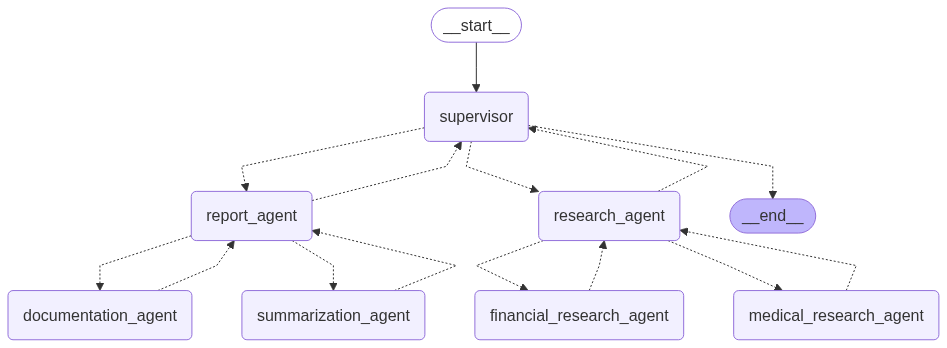

In [28]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
state = {"messages": [HumanMessage(content="What is the projected GDP growth for China in 2025?")]}
graph.invoke(state)


[DEBUG] User Query: What is the projected GDP growth for China in 2025?
[DEBUG] LLM Raw Response: research_agent
[DEBUG] Routing to agent: research_agent
[DEBUG] Research Supervisor Received Query: What is the projected GDP growth for China in 2025?
[DEBUG] Research Agent Routing Decision: financial_research_agent
[DEBUG] Financial Agent received query: What is the projected GDP growth for China in 2025?
[DEBUG] Leaf agent responded — returning to supervisor
[DEBUG] Found existing AI response — finishing the workflow.


{'messages': [HumanMessage(content='What is the projected GDP growth for China in 2025?', additional_kwargs={}, response_metadata={}, id='3006da6b-da4c-4dd1-bf8b-403df8e2fedf'),
  AIMessage(content=' Financial Insight:\nrevised its forecast for China’s 2025 GDP growth, raising it slightly to 4.6%—up from its earlier projection of 4.3%. This adjustment reflects the positive impact of recent stimulus measures introduced by Beijing to offset lingering weaknesses in consumer demand, property market volatility, and external trade tensions.', additional_kwargs={}, response_metadata={}, id='be299fd9-023a-4800-8692-afbb0d3aa455')]}

In [30]:
state = {"messages": [HumanMessage(content="Write a summary of our Q2 financial performance")]}
graph.invoke(state)


[DEBUG] User Query: Write a summary of our Q2 financial performance
[DEBUG] LLM Raw Response: report_agent
[DEBUG] Routing to agent: report_agent
[DEBUG] Report Supervisor Received Query: Write a summary of our Q2 financial performance
[DEBUG] Report Agent Routing Decision: summarization_agent
[DEBUG] Summarization Agent received: Write a summary of our Q2 financial performance
[DEBUG] Leaf agent responded — returning to supervisor
[DEBUG] Found existing AI response — finishing the workflow.


{'messages': [HumanMessage(content='Write a summary of our Q2 financial performance', additional_kwargs={}, response_metadata={}, id='0266c87e-4903-440c-b17b-71052233daaf'),
  AIMessage(content=' Summary:\n- Summarize Q2 financial performance.\n- Highlight key metrics and trends.\n- Include revenue, expenses, and profit margins.\n- Note any significant changes compared to previous quarters.\n- Mention factors influencing performance.', additional_kwargs={}, response_metadata={}, id='ab5653fd-53b5-4d80-92cf-a57f7f0af521')]}

In [31]:
state = {"messages": [HumanMessage(content="What are the symptoms of hypertension?")]}
graph.invoke(state)


[DEBUG] User Query: What are the symptoms of hypertension?
[DEBUG] LLM Raw Response: research_agent
[DEBUG] Routing to agent: research_agent
[DEBUG] Research Supervisor Received Query: What are the symptoms of hypertension?
[DEBUG] Research Agent Routing Decision: medical_research_agent
[DEBUG] Medical Agent received query: What are the symptoms of hypertension?
[DEBUG] Leaf agent responded — returning to supervisor
[DEBUG] Found existing AI response — finishing the workflow.


{'messages': [HumanMessage(content='What are the symptoms of hypertension?', additional_kwargs={}, response_metadata={}, id='682efe99-f766-46a4-a630-66d99d8c1a70'),
  AIMessage(content="🔍 Medical Insight:\nThe symptoms of severe hypertension are so general that they may look like a number of health conditions. Among those conditions are:Â\n\nDehydration. If your body doesn't have enough fluids, you might get symptoms that are also common with extremely high blood pressure, including nausea, dizziness, fatigue, or confusion. That happens in part because staying hydrated helps Â maintain normal blood pressure. [...] High blood pressure â\x80\x93 also called hypertension â\x80\x93 can lead to serious complications, including stroke, heart disease, kidney disease, and eye problems. Most people with high blood pressure don't have any symptoms until it's severe. Instead of relying on symptoms to alert you, have your blood pressure checked regularly. You may want to learn how to monitor your 

In [32]:
state = {"messages": [HumanMessage(content="What are some good project management tools?")]}
graph.invoke(state)


[DEBUG] User Query: What are some good project management tools?
[DEBUG] LLM Raw Response: none
[DEBUG] Supervisor classified query as unrelated or done — finishing.


{'messages': [HumanMessage(content='What are some good project management tools?', additional_kwargs={}, response_metadata={}, id='7603fbb6-b844-48dc-994d-857849802aae')]}